# Kazakh AI-Text Detection — Data Curation & Clean-Dataset Extraction

This notebook turns the raw `train/dev/test` splits into a **clean, leakage-free, well-documented dataset** ready
for AI-Generated vs AI-Obfuscated vs Human detection. It is driven by the findings of the EDA notebook.

## What the EDA revealed (and what we fix here)
| # | Finding (from EDA on 8,998 rows) | Action in this notebook |
|---|----------------------------------|-------------------------|
| 1 | **~3,000 redundant copies** — only ~5,998 unique texts; 66.7% of rows are in a duplicate group | Exact + normalised deduplication |
| 2 | **Cross-split leakage**: global dup count (3,000) > within-split sum (1,920) → ~1,080 texts span train/dev/test | Pool everything, dedup, then **re-split leakage-free** |
| 3 | **AI-Obfuscated is 100% duplicated** (2,000 rows); Human 60.6%, AI-Gen 54.1% | Dedup per class; report survivors |
| 4 | **Length confound**: AI-Obf ~37 words vs Human ~94 / AI-Gen ~87 (AI-Gen vs AI-Obf rank-biserial -0.68) | Report it; optional length-matched subset |
| 5 | `source` -> `label` is deterministic (Cramer's V = 1.0) | Keep `source` only for stratification; never a feature |
| 6 | 40 rows with unusual Unicode; replacement chars possible; curly quotes / whitespace noise | Unicode NFC normalisation + cleaning |
| 7 | `emoji_count` all zero; ~9.5% of texts exceed 512 tokens | Drop dead feature; document truncation |
| 8 | 0 label-conflicting duplicates; splits proportionally stratified | Safe to merge + re-stratify by label |

## Outputs
`clean_data/clean_train.json`, `clean_dev.json`, `clean_test.json` (schema `{text, label, source}`), a combined
`clean_all.json`, an optional length-matched training subset, a `removal_log.csv`, and a `DATA_CARD.md`.


## 0. Configuration

All knobs live here. Defaults are conservative and reproducible. `FUZZY_NEAR_DUP` enables paraphrase-level
near-duplicate merging (slower); `MAKE_LENGTH_MATCHED` additionally emits a length-balanced training subset used
to test whether a model relies on the length shortcut rather than real stylistic signal.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from __future__ import annotations
import os
import re
import json
import random
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):
        return x

# ---- reproducibility ----
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---- pipeline switches ----
FUZZY_NEAR_DUP = False        # merge paraphrase-level near-duplicates (char n-gram cosine)
NEAR_DUP_THRESHOLD = 0.92     # cosine similarity above which two same-class texts are near-duplicates
MAKE_LENGTH_MATCHED = True    # also export a length-balanced training subset (robustness ablation)

# ---- quality thresholds ----
MIN_WORDS = 5                 # drop texts shorter than this (too short to attribute reliably)
MAX_UNUSUAL_UNICODE_RATIO = 0.05  # drop rows where >5% of chars are non-Cyrillic/Latin/punct after cleaning

# ---- split ratios (leakage-free re-split) ----
SPLIT_RATIOS = {'train': 0.70, 'dev': 0.15, 'test': 0.15}

# ---- paths ----
OUT_DIR = Path('clean_data')
FIG_DIR = OUT_DIR / 'figures'
for _d in (OUT_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: 'Human', 1: 'AI-Generated', 2: 'AI-Obfuscated'}
PALETTE = {'Human': '#2E86AB', 'AI-Generated': '#E4572E', 'AI-Obfuscated': '#8FB339'}
CLASS_ORDER = [LABEL_NAMES[k] for k in sorted(LABEL_NAMES)]
sns.set_theme(style='whitegrid')
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'

removal_log = []   # collects (stage, reason, n_removed) for the data card
print('Config ready. FUZZY_NEAR_DUP =', FUZZY_NEAR_DUP, '| MAKE_LENGTH_MATCHED =', MAKE_LENGTH_MATCHED)


Config ready. FUZZY_NEAR_DUP = False | MAKE_LENGTH_MATCHED = True


## 1. Load and pool the raw splits

Because the raw splits leak into each other (identical texts appear in more than one split), we cannot trust the
original split boundaries. We pool all rows, remember the original split for auditing, and later build fresh,
leakage-free splits from the deduplicated data.


In [ ]:
def find_data_file(fname: str) -> Path:
    for c in [Path(fname), Path('..') / fname, Path('data') / fname]:
        if c.exists():
            return c
    return Path(fname)

def load_split(fname: str, split_name: str) -> pd.DataFrame:
    with open(find_data_file(fname), 'r', encoding='utf-8') as f:
        data = json.load(f)
    frame = pd.DataFrame(data)
    frame['orig_split'] = split_name
    return frame

raw = pd.concat([
    load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/train_set.json', 'train'),
    load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/dev_set.json', 'dev'),
    load_split('/content/drive/MyDrive/IEEE ACCESS/data/interim/test_set.json', 'test'),
], ignore_index=True)
raw['text'] = raw['text'].astype(str)
raw['label_name'] = raw['label'].map(LABEL_NAMES)
N_RAW = len(raw)
print(f'Pooled raw rows: {N_RAW}')
print(raw['label_name'].value_counts().reindex(CLASS_ORDER))


Pooled raw rows: 8998
label_name
Human            3299
AI-Generated     3699
AI-Obfuscated    2000
Name: count, dtype: int64


## 2. Text cleaning (Unicode-safe for Kazakh)

We apply NFC Unicode normalisation, remove the Unicode replacement character (a sign of prior encoding damage),
standardise curly quotes and dashes to ASCII, and collapse repeated whitespace/newlines. Kazakh-specific letters
(Ә Ғ Қ Ң Ө Ұ Ү Һ І) are preserved — we only touch punctuation, control, and whitespace characters.


In [ ]:
REPLACEMENT_CHAR = chr(0xFFFD)
# Map fancy punctuation to plain ASCII equivalents (keeps text but removes noise variance).
QUOTE_MAP = {
    ord('“'): '"', ord('”'): '"', ord('„'): '"', ord('‟'): '"',
    ord('’'): "'", ord('‘'): "'", ord('‚'): "'", ord('‛'): "'",
    ord('«'): '"', ord('»'): '"', ord('—'): '-', ord('–'): '-', ord('―'): '-',
    ord('…'): '...', 0x00A0: ' ', 0x200B: '', 0x200C: '', 0x200D: '', 0xFEFF: '',
}

def clean_text(text: str) -> str:
    # Unicode-normalise, strip damage/zero-width, unify punctuation, collapse whitespace.
    t = unicodedata.normalize('NFC', str(text))
    t = t.replace(REPLACEMENT_CHAR, '')
    t = t.translate(QUOTE_MAP)
    # remove non-printable / control characters (keep normal whitespace)
    t = ''.join(ch for ch in t if ch == '\n' or ch == '\t' or unicodedata.category(ch)[0] != 'C')
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n{3,}', '\n\n', t)
    t = re.sub(r'\s+\n', '\n', t)
    return t.strip()

raw['text_clean'] = [clean_text(t) for t in tqdm(raw['text'], desc='cleaning')]
changed = int((raw['text_clean'] != raw['text']).sum())
print(f'Rows whose text changed during cleaning: {changed} ({100*changed/N_RAW:.1f}%)')


cleaning:   0%|          | 0/8998 [00:00<?, ?it/s]

Rows whose text changed during cleaning: 4460 (49.6%)


## 3. Quality filtering

We drop rows that are unusable for reliable authorship attribution: empty after cleaning, punctuation-only,
number-only, shorter than `MIN_WORDS`, or dominated by unusual (non-Kazakh/Latin) characters. Every removal is
logged so the data card is fully auditable. (The EDA found none of these in bulk, but the filter makes the
pipeline robust and self-documenting.)


In [ ]:
def word_count(text: str) -> int:
    return len(text.split())

def unusual_ratio(text: str) -> float:
    # Fraction of non-space chars outside Cyrillic/Latin/punct/number/symbol.
    chars = [c for c in text if not c.isspace()]
    if not chars:
        return 0.0
    bad = 0
    for ch in chars:
        o = ord(ch)
        if 0x0400 <= o <= 0x04FF or (0x41 <= o <= 0x5A) or (0x61 <= o <= 0x7A):
            continue
        if unicodedata.category(ch)[0] in ('P', 'N', 'S'):
            continue
        bad += 1
    return bad / len(chars)

def is_only_punct(text: str) -> bool:
    s = text.strip()
    return len(s) > 0 and not any(c.isalnum() for c in s)

def is_only_numbers(text: str) -> bool:
    s = text.strip()
    return bool(s) and any(c.isdigit() for c in s) and not any(c.isalpha() for c in s)

wc = raw['text_clean'].map(word_count)
reasons = pd.Series('keep', index=raw.index)
reasons[raw['text_clean'].str.len() == 0] = 'empty'
reasons[(reasons == 'keep') & raw['text_clean'].map(is_only_punct)] = 'only_punctuation'
reasons[(reasons == 'keep') & raw['text_clean'].map(is_only_numbers)] = 'only_numbers'
reasons[(reasons == 'keep') & (wc < MIN_WORDS)] = 'too_short'
reasons[(reasons == 'keep') & (raw['text_clean'].map(unusual_ratio) > MAX_UNUSUAL_UNICODE_RATIO)] = 'unusual_unicode'

for r, n in reasons[reasons != 'keep'].value_counts().items():
    removal_log.append({'stage': 'quality_filter', 'reason': r, 'n_removed': int(n)})

kept = raw[reasons == 'keep'].copy()
print('Removed by quality filter:')
print(reasons[reasons != 'keep'].value_counts().to_string() or '  (none)')
print(f'\nRows after quality filter: {len(kept)} / {N_RAW}')


Removed by quality filter:
Series([], )

Rows after quality filter: 8998 / 8998


## 4. Deduplication (exact + normalised) and leakage audit

This is the most consequential step. We build a normalised key (lower-cased, alphanumeric-only) so texts that
differ only in punctuation/whitespace/case collapse to the same key. We first **quantify the cross-split
leakage** in the raw data, then keep exactly one representative per key. Because the EDA confirmed 0
label-conflicting duplicates, deduplication is unambiguous; where a rare conflict exists we keep the majority
label and log it.


In [ ]:
def norm_key(text: str) -> str:
    return ''.join(ch for ch in text.lower() if ch.isalnum())

kept['key'] = kept['text_clean'].map(norm_key)

# --- leakage audit: how many keys appear in more than one original split? ---
splits_per_key = kept.groupby('key')['orig_split'].nunique()
leaky_keys = splits_per_key[splits_per_key > 1]
leaked_rows = int(kept['key'].isin(leaky_keys.index).sum())
print(f'Unique keys                       : {kept["key"].nunique()}')
print(f'Keys spanning >1 original split   : {len(leaky_keys)}')
print(f'Rows involved in cross-split leak : {leaked_rows} ({100*leaked_rows/len(kept):.1f}% of kept rows)')

# --- label-conflict check ---
labels_per_key = kept.groupby('key')['label'].nunique()
conflict_keys = labels_per_key[labels_per_key > 1].index
print(f'Keys with conflicting labels      : {len(conflict_keys)}')


Unique keys                       : 5998
Keys spanning >1 original split   : 1080
Rows involved in cross-split leak : 2160 (24.0% of kept rows)
Keys with conflicting labels      : 0


In [ ]:
# Resolve any label conflicts to the majority label (logged), then keep one row per key.
if len(conflict_keys) > 0:
    majority = (kept[kept['key'].isin(conflict_keys)]
                .groupby('key')['label']
                .agg(lambda s: s.value_counts().index[0]))
    kept.loc[kept['key'].isin(conflict_keys), 'label'] = kept.loc[
        kept['key'].isin(conflict_keys), 'key'].map(majority)
    kept['label_name'] = kept['label'].map(LABEL_NAMES)
    removal_log.append({'stage': 'dedup', 'reason': 'label_conflict_resolved',
                        'n_removed': int(len(conflict_keys))})

n_before = len(kept)
# Prefer the longest surviving text as the representative (most complete copy).
kept = (kept.assign(_len=kept['text_clean'].str.len())
            .sort_values('_len', ascending=False)
            .drop_duplicates('key', keep='first')
            .drop(columns='_len')
            .reset_index(drop=True))
removal_log.append({'stage': 'dedup', 'reason': 'exact_normalised_duplicate',
                    'n_removed': int(n_before - len(kept))})

print(f'Rows before dedup: {n_before}')
print(f'Rows after dedup : {len(kept)}  (removed {n_before - len(kept)})')
print('\nUnique rows per class after dedup:')
print(kept['label_name'].value_counts().reindex(CLASS_ORDER))


Rows before dedup: 8998
Rows after dedup : 5998  (removed 3000)

Unique rows per class after dedup:
label_name
Human            2299
AI-Generated     2699
AI-Obfuscated    1000
Name: count, dtype: int64


## 5. Optional: paraphrase-level near-duplicate merging

Exact/normalised dedup removes byte-level copies but not slightly reworded near-duplicates, which are especially
plausible for the AI-Obfuscated (paraphrase) class and can still leak signal across splits. When
`FUZZY_NEAR_DUP=True`, we cluster near-duplicates **within each class** using character n-gram TF-IDF cosine
similarity and a union-find, then keep one representative per cluster. Clusters also become the grouping unit for
the leakage-free split so that near-duplicates never straddle train/dev/test.


In [ ]:
class UnionFind:
    def __init__(self, n: int):
        self.p = list(range(n))
    def find(self, x: int) -> int:
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x
    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[ra] = rb

def cluster_near_duplicates(frame: pd.DataFrame, threshold: float) -> pd.Series:
    # Assign a cluster id to every row; near-duplicates within a class share a cluster.
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.neighbors import NearestNeighbors
    cluster_id = pd.Series(-1, index=frame.index, dtype=int)
    next_id = 0
    for name in CLASS_ORDER:
        idx = frame.index[frame['label_name'] == name]
        if len(idx) == 0:
            continue
        texts = frame.loc[idx, 'text_clean'].tolist()
        vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2)
        X = vec.fit_transform(texts)
        k = min(10, len(idx))
        nn = NearestNeighbors(n_neighbors=k, metric='cosine').fit(X)
        dist, nbr = nn.kneighbors(X)
        uf = UnionFind(len(idx))
        for i in range(len(idx)):
            for j_pos, d in zip(nbr[i], dist[i]):
                if i != j_pos and (1.0 - d) >= threshold:
                    uf.union(i, j_pos)
        roots = {}
        for i, global_i in enumerate(idx):
            r = uf.find(i)
            if r not in roots:
                roots[r] = next_id
                next_id += 1
            cluster_id.loc[global_i] = roots[r]
    return cluster_id

if FUZZY_NEAR_DUP:
    kept['group'] = cluster_near_duplicates(kept, NEAR_DUP_THRESHOLD)
    n_before = len(kept)
    kept = (kept.assign(_len=kept['text_clean'].str.len())
                .sort_values('_len', ascending=False)
                .drop_duplicates('group', keep='first')
                .drop(columns='_len')
                .reset_index(drop=True))
    removal_log.append({'stage': 'near_dup', 'reason': 'fuzzy_near_duplicate',
                        'n_removed': int(n_before - len(kept))})
    print(f'Near-duplicate merging removed {n_before - len(kept)} rows -> {len(kept)} remain')
else:
    kept['group'] = np.arange(len(kept))   # each unique text is its own group
    print('FUZZY_NEAR_DUP disabled: each unique text is its own group.')


FUZZY_NEAR_DUP disabled: each unique text is its own group.


## 6. Leakage-free, stratified re-split

We assign whole groups (unique texts, or near-duplicate clusters) to train/dev/test so that no text or its
near-duplicate ever crosses a split boundary. Assignment is stratified by label (done per class) and greedy on
row counts to hit the target ratios closely. This replaces the leaky original splits with clean ones.


In [ ]:
def grouped_stratified_split(frame: pd.DataFrame, ratios: dict, seed: int) -> pd.Series:
    rng = np.random.default_rng(seed)
    assignment = pd.Series(index=frame.index, dtype=object)
    group_label = frame.groupby('group')['label_name'].agg(lambda s: s.value_counts().index[0])
    group_size = frame.groupby('group').size()
    split_names = list(ratios.keys())
    for name in CLASS_ORDER:
        groups = group_label[group_label == name].index.to_numpy()
        rng.shuffle(groups)
        total = int(group_size[groups].sum())
        target = {s: total * ratios[s] for s in split_names}
        running = {s: 0 for s in split_names}
        g2s = {}
        for g in groups:
            s = max(split_names, key=lambda k: target[k] - running[k])
            g2s[g] = s
            running[s] += int(group_size[g])
        mask = frame['group'].isin(groups)
        assignment[mask] = frame.loc[mask, 'group'].map(g2s)
    return assignment

kept['split'] = grouped_stratified_split(kept, SPLIT_RATIOS, RANDOM_SEED)

dist = pd.crosstab(kept['split'], kept['label_name']).reindex(index=['train', 'dev', 'test'], columns=CLASS_ORDER)
print('Clean split x class counts:')
print(dist)
print('\nProportions within split:')
print((dist.div(dist.sum(axis=1), axis=0) * 100).round(1))


Clean split x class counts:
label_name  Human  AI-Generated  AI-Obfuscated
split                                         
train        1609          1889            700
dev           345           405            150
test          345           405            150

Proportions within split:
label_name  Human  AI-Generated  AI-Obfuscated
split                                         
train        38.3          45.0           16.7
dev          38.3          45.0           16.7
test         38.3          45.0           16.7


In [ ]:
# --- verify: zero text/key overlap across the new splits ---
sets = {s: set(kept.loc[kept['split'] == s, 'key']) for s in ['train', 'dev', 'test']}
overlaps = {
    'train_dev': len(sets['train'] & sets['dev']),
    'train_test': len(sets['train'] & sets['test']),
    'dev_test': len(sets['dev'] & sets['test']),
}
print('Cross-split key overlaps (must all be 0):', overlaps)
assert sum(overlaps.values()) == 0, 'Leakage detected in new splits!'
print('PASS: new splits are leakage-free.')


Cross-split key overlaps (must all be 0): {'train_dev': 0, 'train_test': 0, 'dev_test': 0}
PASS: new splits are leakage-free.


## 7. Before/after diagnostics

Visual confirmation of what curation changed: class balance before vs after, and the length distribution per
class in the clean data (the length gap between AI-Obfuscated and the other classes is the key confound to keep
in mind when interpreting model results).


/tmp/ipykernel_1070/3542125702.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=kept, x='label_name', y='word_count', order=CLASS_ORDER, palette=PALETTE,


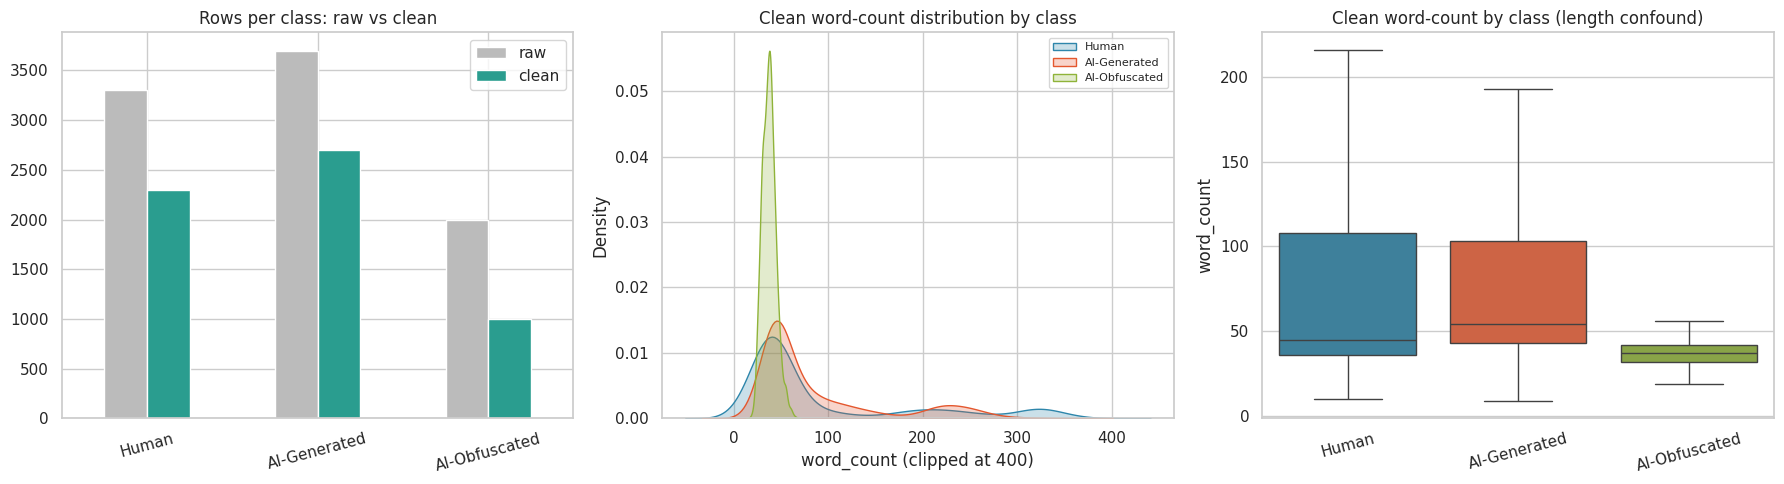

Median words by class (clean):
label_name
Human            45.0
AI-Generated     54.0
AI-Obfuscated    37.0
Name: word_count, dtype: float64


In [ ]:
kept['word_count'] = kept['text_clean'].map(word_count)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
before = raw['label_name'].value_counts().reindex(CLASS_ORDER)
after = kept['label_name'].value_counts().reindex(CLASS_ORDER)
cmp = pd.DataFrame({'raw': before, 'clean': after})
cmp.plot(kind='bar', ax=axes[0], color=['#bbbbbb', '#2A9D8F'])
axes[0].set_title('Rows per class: raw vs clean')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelrotation=15)

for name in CLASS_ORDER:
    sns.kdeplot(kept.loc[kept['label_name'] == name, 'word_count'].clip(upper=400),
                ax=axes[1], label=name, color=PALETTE[name], fill=True, alpha=0.25, common_norm=False)
axes[1].set_title('Clean word-count distribution by class')
axes[1].set_xlabel('word_count (clipped at 400)')
axes[1].legend(fontsize=8)

sns.boxplot(data=kept, x='label_name', y='word_count', order=CLASS_ORDER, palette=PALETTE,
            showfliers=False, ax=axes[2])
axes[2].set_title('Clean word-count by class (length confound)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', labelrotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'clean_diagnostics.png')
plt.show()
print('Median words by class (clean):')
print(kept.groupby('label_name')['word_count'].median().reindex(CLASS_ORDER))


## 8. Optional: length-matched training subset (robustness control)

Because AI-Obfuscated texts are much shorter, a classifier can cheat by using length. To measure real stylistic
signal we build a training subset in which the three classes share a comparable word-count distribution: we bin
by word-count deciles and, in each bin, downsample every class to the size of the smallest class. Train a model
here and compare with the full clean set — a large drop means the model was leaning on length. This subset is an
**ablation aid, not** a replacement for the full clean training set.


In [ ]:
if MAKE_LENGTH_MATCHED:
    train = kept[kept['split'] == 'train'].copy()
    train['wc_bin'] = pd.qcut(train['word_count'], q=10, duplicates='drop')
    parts = []
    rng = np.random.default_rng(RANDOM_SEED)
    for _, grp in train.groupby('wc_bin'):
        per_class = grp['label_name'].value_counts()
        if len(per_class) < len(CLASS_ORDER):
            continue
        n = int(per_class.min())
        for name in CLASS_ORDER:
            rows = grp[grp['label_name'] == name]
            take = rows.sample(n=min(n, len(rows)), random_state=int(rng.integers(1e9)))
            parts.append(take)
    length_matched = pd.concat(parts).drop(columns='wc_bin').reset_index(drop=True)
    print(f'Length-matched training subset: {len(length_matched)} rows')
    print(length_matched['label_name'].value_counts().reindex(CLASS_ORDER))
    print('Median words by class (should be close):')
    print(length_matched.groupby('label_name')['word_count'].median().reindex(CLASS_ORDER))
else:
    length_matched = None
    print('MAKE_LENGTH_MATCHED disabled.')


Length-matched training subset: 1662 rows
label_name
Human            554
AI-Generated     554
AI-Obfuscated    554
Name: count, dtype: int64
Median words by class (should be close):
label_name
Human            39.0
AI-Generated     39.0
AI-Obfuscated    39.0
Name: word_count, dtype: float64


/tmp/ipykernel_1070/4260292653.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, grp in train.groupby('wc_bin'):


## 9. Export clean dataset, removal log & data card

We write the clean splits back out in the original `{text, label, source}` schema (using the cleaned text), plus
a combined file, the optional length-matched training subset, a `removal_log.csv`, and a human-readable
`DATA_CARD.md` documenting every transformation for reproducibility and for the IEEE Access write-up.


In [ ]:
def export_split(frame: pd.DataFrame, path: Path) -> None:
    records = frame[['text_clean', 'label', 'source']].rename(columns={'text_clean': 'text'})
    records = records.assign(label=records['label'].astype(int)).to_dict(orient='records')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    print(f'  wrote {len(records):>5} rows -> {path}')

print('Writing clean splits:')
for s in ['train', 'dev', 'test']:
    export_split(kept[kept['split'] == s], OUT_DIR / f'clean_{s}.json')
export_split(kept, OUT_DIR / 'clean_all.json')
if length_matched is not None:
    export_split(length_matched, OUT_DIR / 'clean_train_length_matched.json')

# Also a flat CSV for convenience.
kept[['text_clean', 'label', 'label_name', 'source', 'split', 'orig_split', 'word_count']] \
    .rename(columns={'text_clean': 'text'}).to_csv(OUT_DIR / 'clean_all.csv', index=False)

log_df = pd.DataFrame(removal_log)
log_df.to_csv(OUT_DIR / 'removal_log.csv', index=False)
print('\nRemoval log:')
print(log_df.to_string(index=False) if len(log_df) else '  (nothing removed)')


Writing clean splits:
  wrote  4198 rows -> clean_data/clean_train.json
  wrote   900 rows -> clean_data/clean_dev.json
  wrote   900 rows -> clean_data/clean_test.json
  wrote  5998 rows -> clean_data/clean_all.json
  wrote  1662 rows -> clean_data/clean_train_length_matched.json

Removal log:
stage                     reason  n_removed
dedup exact_normalised_duplicate       3000


In [ ]:
# Build the data card (dependency-free: uses to_string, no tabulate needed).
def class_line(frame):
    vc = frame['label_name'].value_counts().reindex(CLASS_ORDER)
    return ', '.join(f'{k}={int(v)}' for k, v in vc.items())

total_removed = int(N_RAW - len(kept))
card = []
card.append('# Data Card — Clean Kazakh AI-Text Detection Dataset\n\n')
card.append(f'- Source: pooled raw train/dev/test ({N_RAW} rows)\n')
card.append(f'- Final clean rows: {len(kept)} (removed {total_removed}, {100*total_removed/N_RAW:.1f}%)\n')
card.append(f'- Class counts (clean): {class_line(kept)}\n')
card.append(f'- Split ratios: {SPLIT_RATIOS}\n')
card.append('- Leakage-free: verified 0 key overlap across train/dev/test\n')
card.append(f'- FUZZY_NEAR_DUP={FUZZY_NEAR_DUP}, MIN_WORDS={MIN_WORDS}, seed={RANDOM_SEED}\n\n')
card.append('## Transformations applied\n')
card.append('1. NFC Unicode normalisation; removed replacement/zero-width/control chars; unified quotes & dashes; collapsed whitespace.\n')
card.append('2. Quality filter: dropped empty, punctuation-only, number-only, <MIN_WORDS words, and >5% unusual-Unicode rows.\n')
card.append('3. Exact + normalised dedup (kept longest representative per key); label conflicts resolved to majority.\n')
card.append('4. Optional paraphrase-level near-dup merging (char n-gram cosine).\n')
card.append('5. Leakage-free, label-stratified, group-respecting re-split.\n\n')
card.append('## Known confound\n')
card.append('AI-Obfuscated texts are markedly shorter than Human/AI-Generated. Use clean_train_length_matched.json to test length-independence, and report length-stratified metrics. Never use `source` as a feature (it is deterministic w.r.t. label).\n\n')
card.append('## Removal log\n')
card.append('```\n')
card.append((log_df.to_string(index=False) if len(log_df) else '(nothing removed)') + '\n')
card.append('```\n')
with open(OUT_DIR / 'DATA_CARD.md', 'w', encoding='utf-8') as f:
    f.write(''.join(card))
print('Wrote', OUT_DIR / 'DATA_CARD.md')
print(''.join(card))


Wrote clean_data/DATA_CARD.md
# Data Card — Clean Kazakh AI-Text Detection Dataset

- Source: pooled raw train/dev/test (8998 rows)
- Final clean rows: 5998 (removed 3000, 33.3%)
- Class counts (clean): Human=2299, AI-Generated=2699, AI-Obfuscated=1000
- Split ratios: {'train': 0.7, 'dev': 0.15, 'test': 0.15}
- Leakage-free: verified 0 key overlap across train/dev/test
- FUZZY_NEAR_DUP=False, MIN_WORDS=5, seed=42

## Transformations applied
1. NFC Unicode normalisation; removed replacement/zero-width/control chars; unified quotes & dashes; collapsed whitespace.
2. Quality filter: dropped empty, punctuation-only, number-only, <MIN_WORDS words, and >5% unusual-Unicode rows.
3. Exact + normalised dedup (kept longest representative per key); label conflicts resolved to majority.
4. Optional paraphrase-level near-dup merging (char n-gram cosine).
5. Leakage-free, label-stratified, group-respecting re-split.

## Known confound
AI-Obfuscated texts are markedly shorter than Human/AI-Generated.

## 10. Summary & how to use the clean data

**What you now have (in `clean_data/`):**
- `clean_train.json` / `clean_dev.json` / `clean_test.json` — deduplicated, Unicode-clean, **leakage-free**,
  label-stratified splits in the original `{text, label, source}` schema.
- `clean_all.json` / `clean_all.csv` — the full curated corpus.
- `clean_train_length_matched.json` — length-balanced training subset for the length-confound ablation.
- `removal_log.csv` and `DATA_CARD.md` — full provenance for the paper.

**Recommended modelling protocol:**
1. Train on `clean_train.json`, tune on `clean_dev.json`, report once on `clean_test.json`.
2. Always report **macro-F1 and per-class F1** (mild imbalance) and a **length-stratified** breakdown.
3. Include two controls: a **length-only baseline** and a model trained on the **length-matched** subset — the
   gap tells you how much accuracy is genuine style vs the length shortcut.
4. The hard pair is **Human vs AI-Generated** (small length effect); AI-Obfuscated is easy on length alone, so
   scrutinise it with the length controls.
5. Baselines: TF-IDF (word + char 3-5 grams) + Linear SVM/LogReg. Transformers: fine-tune `xlm-roberta-base`
   (or a Kazakh/Turkic encoder) at `max_len=512`; test robustness to paraphrase/back-translation attacks.
6. Never feed `source` (or any length-derived shortcut) to the model as an explicit feature.


In [ ]:
train_df = pd.read_json("/content/clean_data/clean_train.json")
dev_df = pd.read_json("/content/clean_data/clean_dev.json")
test_df = pd.read_json("/content/clean_data/clean_test.json")

In [ ]:
def normalize_source(source_text):
    source_text = source_text.replace('TQ_', '')
    source_text = source_text.replace('_text', '')
    return source_text

train_df['source'] = train_df['source'].apply(normalize_source)
dev_df['source'] = dev_df['source'].apply(normalize_source)
test_df['source'] = test_df['source'].apply(normalize_source)

### Normalized `train_df`

In [ ]:
display(train_df.head())

,text,label,source
0,Аспазшы Асхат өзінің аспаздық мансабында үлкен...,1,Story_response
1,Қазақ халқының ұлттық спорт түрлері оның тарих...,0,Reading
2,Аймақтық даму бағдарламалары ел ішіндегі эконо...,0,Reading
3,Жетісу облысы Сарыөзек ауылындағы ескі ғимарат...,0,Summary
4,"""ҚазАвтоЖол"" ұлттық компаниясы Қарағанды облыс...",0,Summary


### Normalized `dev_df`

In [ ]:
display(dev_df.head())

,text,label,source
0,"Көпшілік ауырған жерін емдеп, денсаулығын дұры...",0,Summary
1,Көкпардан ұлттық құрама спортшылары елордадағы...,0,Summary
2,Павлодар облысындағы Бала құқықтары жөніндегі ...,0,Summary
3,Қазақстан Ұлттық Банкі (бұдан әрі - ҚҰБ) 1996 ...,0,Summary
4,Су тасқыны кезеңінің басынан бастап Батыс Қаза...,0,Summary


### Normalized `test_df`

In [ ]:
display(test_df.head())

,text,label,source
0,Биыл оған қатысу үшін Астанаға республика өңір...,0,Summary
1,"Белгілі ақын Ханбибі Есенқараева ""Менің өмірім...",0,Summary
2,Ақтөбе қаласының тұрғыны Тұрар Иниятов шаңырағ...,0,Summary
3,- Кеше жан-жақты және мазмұнды келіссөз жүргіз...,0,Summary
4,Шымкентте әскерге шақырылған жігіт әскери коми...,0,Summary


### Unique values and counts in `source` column of `train_df`

In [ ]:
print(train_df['source'].value_counts())

source
Conversion_response    1058
Conversion             1055
Paraphrase2             700
Summary_response        357
Summary                 339
Story_response          263
Reading                 215
Reading_response        211
Name: count, dtype: int64


### Unique values and counts in `source` column of `dev_df`

In [ ]:
print(dev_df['source'].value_counts())

source
Conversion             229
Conversion_response    220
Paraphrase2            150
Summary                 71
Story_response          71
Summary_response        64
Reading_response        50
Reading                 45
Name: count, dtype: int64


### Unique values and counts in `source` column of `test_df`

In [ ]:
print(test_df['source'].value_counts())

source
Conversion_response    222
Conversion             216
Paraphrase2            150
Summary                 90
Summary_response        78
Story_response          66
Reading_response        39
Reading                 39
Name: count, dtype: int64


In [ ]:
source_name_map = {
    'Conversion_response': 'Conversion',
    'Conversion': 'Conversion',
    'Paraphrase2': 'Paraphrase',
    'Summary_response': 'Summary',
    'Summary': 'Summary',
    'Story_response': 'Story',
    'Reading': 'Reading',
    'Reading_response': 'Reading'
}

train_df['source'] = train_df['source'].map(source_name_map)
dev_df['source'] = dev_df['source'].map(source_name_map)
test_df['source'] = test_df['source'].map(source_name_map)

### Updated `source` column values in `train_df`

In [ ]:
print(train_df['source'].value_counts())

source
Conversion    2113
Paraphrase     700
Summary        696
Reading        426
Story          263
Name: count, dtype: int64


### Updated `source` column values in `dev_df`

In [ ]:
print(dev_df['source'].value_counts())

source
Conversion    449
Paraphrase    150
Summary       135
Reading        95
Story          71
Name: count, dtype: int64


### Updated `source` column values in `test_df`

In [ ]:
print(test_df['source'].value_counts())

source
Conversion    438
Summary       168
Paraphrase    150
Reading        78
Story          66
Name: count, dtype: int64


## Resources

Saving the cleaned dataframes to JSON files.

In [ ]:
train_df.to_json('train_cleaned.json', orient='records', indent=2)
dev_df.to_json('dev_cleaned.json', orient='records', indent=2)
test_df.to_json('test_cleaned.json', orient='records', indent=2)

print('Cleaned train_df saved to train_cleaned.json')
print('Cleaned dev_df saved to dev_cleaned.json')
print('Cleaned test_df saved to test_cleaned.json')

Cleaned train_df saved to train_cleaned.json
Cleaned dev_df saved to dev_cleaned.json
Cleaned test_df saved to test_cleaned.json
